# **Actividad 4. Aprendizaje no supervisado con PySpark**

### **Curso: TC5057 - Analísis de Grandes Volúmenes de Datos**
#### **Tecnológico de Monterrey - MNA**
##### **Profesor: Dr. Iván Olmos Pineda**

---

| Nombre | Matrícula |
|--------|----------|
| Ana Bonavides Aguilar | A01423281 |

**Modalidad:** Individual

**Dataset:** GTEx Analysis V10 (Genotype-Tissue Expression) - perfil de expresión génica humana

## Contexto del problema

En el proyecto de equipo trabajo con el dataset GTEx, que mide expresión génica (TPM) en muestras de tejido humano sano. En la Actividad 3 entrené dos modelos supervisados (Random Forest y Logistic Regression) para predecir el **grupo de tejido** (`TISSUE_GROUP`, 5 clases) a partir del perfil de expresión génica. Ambos modelos alcanzaron accuracy > 0.94.

En esta actividad cambia la pregunta. Ahora no le doy al modelo las etiquetas - le doy solo los perfiles de expresión y le pido que descubra estructura por su cuenta:

> Sin saber qué tejido es cada muestra, ¿logra un algoritmo de clustering agrupar las muestras de manera que los grupos descubiertos coincidan con los grupos biológicos de tejido reales?

Esto importa por dos razones:
1. **Validación biológica:** si los clusters descubiertos sin labels coinciden con tejidos reales, refuerza que el perfil de expresión es discriminativo (lo que ya habíamos visto desde el lado supervisado, pero ahora confirmado desde el lado no supervisado).
2. **Detección de anomalías:** una vez que tengo clusters que representan tejidos sanos, una muestra nueva que no encaje bien en ningún cluster (silhouette negativo, distancia grande al centroide más cercano) es candidata a ser anómala. Esa es la conexión con el caso del proyecto (muestras de astronautas o condiciones extremas).

## Mejoras respecto a la Actividad 3

El feedback de la actividad pasada sugirió tres líneas concretas de mejora. Las incorporo explícitamente en esta entrega:

1. **Validación cruzada:** en clustering esto se traduce a un k-fold de **estabilidad de clusters**. Entreno K-Means en k-1 folds, aplico `.transform()` al fold restante, y mido cómo varía el silhouette entre folds. Reporto media ± desvío en vez de un solo número.
2. **Estrategias alternativas de selección de características:** comparo la selección por **varianza univariada** (la de Act 3) contra **PCA** (reducción por varianza multivariada). Entreno los modelos sobre ambos pre-procesamientos y veo cuál da mejor estructura.
3. **Interpretación biológica profunda:** construyo una tabla cluster -> top genes que más lo definen (los que más se desvían del centroide global), con sus nombres y rol biológico conocido. No solo nombro marcadores famosos como hice en Act 3.

## 1. Introducción teórica

### 1.1 Aprendizaje no supervisado

El **aprendizaje no supervisado** es la rama del aprendizaje automático donde el modelo recibe únicamente datos de entrada $X \in \mathbb{R}^{n \times d}$, sin etiquetas $y$ asociadas. El objetivo es descubrir estructura latente en los datos: agruparlos, simplificarlos, o detectar lo que se desvía.

A diferencia del supervisado, no hay una función de pérdida con respecto a un objetivo conocido. El modelo optimiza un criterio interno (como minimizar la suma de distancias intra-cluster) y la evaluación pasa por métricas que miden la calidad de la estructura encontrada, no la coincidencia con un target.

Tareas principales:

- **Clustering:** particionar las observaciones en grupos homogéneos.
- **Reducción de dimensionalidad:** comprimir features manteniendo la información discriminativa (útil para visualización y como pre-procesamiento).
- **Detección de anomalías:** identificar observaciones que no encajan en la estructra del resto.
- **Reglas de asociación:** descubrir co-ocurrencias en datos transaccionales (mercado, navegación web).

En esta actividad me enfoco en **clustering** porque es la familia más representativa y la que mejor se conecta con mi caso (descubrir si los perfiles de expresión génica se agrupan por tejido sin decirle al modelo cuál es cada tejido).

### 1.2 Algoritmos representativos en la literatura

| Familia | Algoritmo | Idea principal |
|---------|-----------|----------------|
| Clustering particional | K-Means | Asigna cada punto al centroide más cercano y recalcula centroides iterativamente. Distancia Euclidiana. |
| Clustering particional | K-Medoids (PAM) | Como K-Means pero los centros son puntos reales del dataset. Más robusto a outliers. |
| Clustering jerárquico | Aglomerativo / Divisivo | Construye un dendrograma fusionando o partiendo clusters. No requiere k a priori. |
| Clustering basado en densidad | DBSCAN, HDBSCAN | Agrupa regiones densas separadas por regiones poco densas. Detecta outliers naturalmente. |
| Clustering probabilístico | Gaussian Mixture Model (GMM) | Modela los datos como una mezcla de gaussianas. Soft clustering. |
| Clustering espectral | Spectral Clustering | Usa autovectores de la matriz de similitud. Bueno para clusters no convexos. |
| Reducción dimensionalidad | PCA | Proyecta a los ejes de mayor varianza. Lineal. |
| Reducción dimensionalidad | t-SNE, UMAP | Preservan vecindarios locales. No lineales, útiles para visualización. |
| Asociación | Apriori, FP-Growth | Encuentran reglas de co-ocurrencia frecuentes. |
| Anomalías | Isolation Forest, One-Class SVM | Modelan la distribución normal y miden cuánto se desvía cada punto. |

### 1.3 Algoritmos disponibles en PySpark

PySpark expone implementaciones distribuidas en `pyspark.ml.clustering` y herramientas asociadas en `pyspark.ml.feature`.

**`pyspark.ml.clustering`:**
- `KMeans` - inicialización k-means|| (paralela), distancia Euclidiana.
- `BisectingKMeans` - clustering jerárquico divisivo. Empieza con un cluster y lo va partiendo en dos hasta llegar a k. Suele dar particiones más estables que K-Means estándar.
- `GaussianMixture` - GMM con EM. Soft clustering (cada punto recibe una probabilidad por cluster).
- `LDA (Latent Dirichlet Allocation)` - topic modeling probabilístico, pensado para datos tipo bag-of-words.
- `PowerIterationClustering` - clustering espectral basado en una matriz de similitud pre-computada.

**`pyspark.ml.feature` (relevantes para no supervisado):**
- `PCA` - reducción de dimensionalidad lineal.
- `StandardScaler`, `MinMaxScaler`, `RobustScaler` - escalado de features (obligatorio antes de K-Means).
- `VectorAssembler` - construye la columna `features` que esperan los modelos.
- `Word2Vec` - embeddings de palabras.

**`pyspark.ml.evaluation`:**
- `ClusteringEvaluator` - calcula silhouette score (la métrica interna estándar para clustering).

**Lo que no hay nativamente en PySpark:** DBSCAN, HDBSCAN, t-SNE, UMAP, Spectral Clustering estándar. Para usar esos algoritmos habría que llevar los datos a sklearn.

### 1.4 Algoritmos elegidos para esta actividad

Voy a entrenar y comparar **dos** modelos de clustering, siguiendo el mismo patrón que usé en Actividad 3 (RF vs LR): dos algoritmos con supuestos distintos para ver cuál captura mejor la estructura de mis datos.

1. **K-Means** - clustering particional clásico, basado en distancia Euclidiana a centroides. Es el más representativo del clustering particional y la elección estándar para datos numéricos.
2. **Bisecting K-Means** - clustering jerárquico divisivo. Empieza con un único cluster y lo va partiendo en dos recursivamente hasta llegar a k. La hipótesis es que esto produce particiones más estables porque cada paso usa más información global.

Además, como mejora respecto a Actividad 3, voy a:
- Hacer **validación cruzada (k-fold)** para reportar estabilidad del silhouette en lugar de un solo número.
- Comparar **dos estrategias de feature selection** (varianza univariada vs PCA) sobre el mismo K-Means.
- Profundizar la **interpretación biológica** identificando los genes que definen cada cluster.

**Métricas de evaluación:**
- **Silhouette score** (interna, vía `ClusteringEvaluator`): cohesión vs separación.
- **Inertia / within-cluster sum of squares** (interna, vía `model.summary.trainingCost`): para el método del codo.
- **Adjusted Rand Index (ARI)** y **Normalized Mutual Information (NMI)** (externas, vía sklearn): comparan la partición descubierta contra los grupos de tejido reales que tengo guardados como ground truth.

Las métricas externas son legítimas aquí porque no las uso para entrenar, solo para responder la pregunta "¿coincide lo que descubrió el modelo con la biología IRL?".

## 2. Selección de datos

En esta sección reproduzco la construcción de M y M' que hice en la Actividad 3, ya que la consigna permite reusar la misma muestra reducida. Las celdas siguen la misma estructura para mantener el notebook auto-contenido y trazable.

### 2.1 Setup: imports y sesión de Spark

In [1]:
import sys, os

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import FloatType
from pyspark.sql.functions import split as spark_split

# imports de ML no supervisado
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# metricas externas (no estan en PySpark, las traigo de sklearn)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

# importo las constantes globales del proyecto (rutas + seed + sample step)
sys.path.insert(0, os.path.abspath('../src'))
from GlobalVariables import (
    FILE_PATH, SAMPLE_ATTRS_PATH, SUBJECT_PHENO_PATH, RANDOM_SEED
)

# fijo seeds para reproducibilidad
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'TPM file:           {FILE_PATH}')
print(f'Sample attributes:  {SAMPLE_ATTRS_PATH}')
print(f'Subject phenotypes: {SUBJECT_PHENO_PATH}')
print(f'Seed:               {RANDOM_SEED}')

TPM file:           /Users/annie/mna/big-data/src/data/GTEx_Analysis_2022-06-06_v10_RNASeQCv2.4.2_gene_tpm_non_lcm.gct
Sample attributes:  /Users/annie/mna/big-data/src/data/GTEx_Analysis_v10_Annotations_SampleAttributesDS.txt
Subject phenotypes: /Users/annie/mna/big-data/src/data/GTEx_Analysis_v10_Annotations_SubjectPhenotypesDS.txt
Seed:               42


In [2]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('GTEx_Actividad4_A01423281') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

spark.conf.set('spark.sql.repl.eagerEval.enabled', True)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/01 22:29:55 WARN Utils: Your hostname, AnniesSpaceShip.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.23 instead (on interface en0)
26/06/01 22:29:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 22:29:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### 2.2 Carga de metadatos

Cargo los archivos de anotaciones de GTEx para etiquetar cada muestra con su grupo de tejido. Esta etiqueta NO se usa para entrenar - la mantengo aparte como ground truth para la evaluación externa (ARI / NMI) y para interpretar los clusters después.

In [3]:
# cargo SampleAttributes y me quedo solo con muestras RNASEQ (las que están en el archivo TPM)
sa_df = spark.read.csv(SAMPLE_ATTRS_PATH, sep='\t', header=True) \
    .select('SAMPID', 'SMTS', 'SMAFRZE') \
    .filter(F.col('SMAFRZE') == 'RNASEQ')

# extraigo el ID del donante a partir del SAMPID
sa_df = sa_df.withColumn(
    'SUBJID',
    F.regexp_extract(F.col('SAMPID'), r'^(GTEX-[^-]+)', 1)
)

print(f'Muestras RNASEQ: {sa_df.count():,}')
sa_df.show(3, truncate=False)

Muestras RNASEQ: 19,788
+-----------------------------+-----+-------+----------+
|SAMPID                       |SMTS |SMAFRZE|SUBJID    |
+-----------------------------+-----+-------+----------+
|GTEX-1117F-0005-SM-HL9SH     |Blood|RNASEQ |GTEX-1117F|
|GTEX-1117F-0011-R10b-SM-GI4VE|Brain|RNASEQ |GTEX-1117F|
|GTEX-1117F-0011-R11b-SM-GIN8R|Brain|RNASEQ |GTEX-1117F|
+-----------------------------+-----+-------+----------+
only showing top 3 rows


In [4]:
# cargo fenotipos de donantes para obtener el sexo
sp_df = spark.read.csv(SUBJECT_PHENO_PATH, sep='\t', header=True) \
    .select('SUBJID', 'SEX')

print(f'Donantes: {sp_df.count():,}')
sp_df.show(3)

Donantes: 981
+----------+---+
|    SUBJID|SEX|
+----------+---+
|GTEX-1117F|  2|
|GTEX-111CU|  1|
|GTEX-111FC|  1|
+----------+---+
only showing top 3 rows


In [5]:
# uno ambos para tener tejido + sexo por muestra
meta_df = sa_df.join(sp_df, on='SUBJID', how='inner')

# mapeo SMTS a los 5 grupos de tejido del proyecto de equipo
tissue_group_col = F.when(F.col('SMTS').isin('Brain', 'Nerve'), 'Nervioso') \
    .when(F.col('SMTS').isin('Blood', 'Bone Marrow', 'Spleen'), 'Hematopoyetico') \
    .when(F.col('SMTS').isin('Heart', 'Blood Vessel'), 'Cardiovascular') \
    .when(F.col('SMTS').isin('Muscle', 'Adipose Tissue', 'Skin'), 'Musculoesqueletico') \
    .otherwise('Visceral_Metabolico')

sex_label_col = F.when(F.col('SEX') == '1', 'Masculino').otherwise('Femenino')

meta_df = meta_df \
    .withColumn('TISSUE_GROUP', tissue_group_col) \
    .withColumn('SEX_LABEL', sex_label_col)

# normalizo el nombre de columna (en el archivo TPM los SAMPID tienen guiones reemplazados)
meta_df = meta_df.withColumn(
    'COL_NAME',
    F.regexp_replace(F.regexp_replace(F.col('SAMPID'), '-', '_'), '\\.', '_')
)

print(f'Muestras con metadatos completos: {meta_df.count():,}')
meta_df.select('SAMPID', 'SMTS', 'TISSUE_GROUP', 'SEX_LABEL').show(3, truncate=False)

Muestras con metadatos completos: 19,788
+-----------------------------+-----+--------------+---------+
|SAMPID                       |SMTS |TISSUE_GROUP  |SEX_LABEL|
+-----------------------------+-----+--------------+---------+
|GTEX-1117F-0005-SM-HL9SH     |Blood|Hematopoyetico|Femenino |
|GTEX-1117F-0011-R10b-SM-GI4VE|Brain|Nervioso      |Femenino |
|GTEX-1117F-0011-R11b-SM-GIN8R|Brain|Nervioso      |Femenino |
+-----------------------------+-----+--------------+---------+
only showing top 3 rows


### 2.3 Carga del TPM y construcción de M

Reuso la misma estrategia que en Actividad 3: leo 1 de cada 50 columnas del archivo TPM completo (`SAMPLE_STEP=50`) para tener una M de ~390 muestras manejable individualmente.

In [6]:
# mismo step de muestreo que en Actividad 3 para mantener consistencia
ACT4_SAMPLE_STEP = 50

# leo solo el header del archivo TPM para obtener nombres de columnas
peek = pd.read_csv(FILE_PATH, sep='\t', skiprows=2, nrows=0)
all_col_names = peek.columns.tolist()

# selecciono 1 de cada N columnas de muestra (las dos primeras son Name y Description)
selected_indices = [0, 1] + list(range(2, len(all_col_names), ACT4_SAMPLE_STEP))
selected_cols_raw = [all_col_names[i] for i in selected_indices]
clean_names = [c.replace('-', '_').replace('.', '_') for c in selected_cols_raw]
sample_cols_M = clean_names[2:]

print(f'Total de columnas en el archivo: {len(all_col_names) - 2:,}')
print(f'Columnas seleccionadas para M:   {len(sample_cols_M):,} (1/{ACT4_SAMPLE_STEP})')

Total de columnas en el archivo: 19,616
Columnas seleccionadas para M:   393 (1/50)


In [7]:
# leo el archivo TPM como texto y filtro a filas de genes (las que empiezan con ENSG)
# uso spark.read.text + Spark SQL puro en vez de UDFs porque las funciones nativas
# se quedan en el JVM y evitan el overhead de serializacion via Py4J
raw_df = spark.read.text(FILE_PATH)
gene_df = raw_df.filter(F.col('value').startswith('ENSG'))

# parseo cada línea por tab y elijo solo las columnas que necesito
split_col = spark_split(F.col('value'), '\t')
df_tpm_M = gene_df.select(
    *[split_col.getItem(i).alias(clean_names[idx]) for idx, i in enumerate(selected_indices)]
)

# casteo las columnas de muestra a float
for c in sample_cols_M:
    df_tpm_M = df_tpm_M.withColumn(c, F.col(c).cast(FloatType()))

print(f'M cargada: {df_tpm_M.count():,} genes x {len(sample_cols_M)} muestras')
df_tpm_M.select(clean_names[:4]).show(3)

M cargada: 59,033 genes x 393 muestras
+-----------------+-----------+------------------------+----------------------------+
|             Name|Description|GTEX_1117F_0005_SM_HL9SH|GTEX_111FC_0011_R5a_SM_GIN8L|
+-----------------+-----------+------------------------+----------------------------+
|ENSG00000223972.5|    DDX11L1|                     0.0|                         0.0|
|ENSG00000227232.5|     WASH7P|                 1.33343|                     3.44305|
|ENSG00000278267.1|  MIR6859-1|                     0.0|                    0.365439|
+-----------------+-----------+------------------------+----------------------------+
only showing top 3 rows


### 2.4 Construcción de M' por muestreo estratificado

Aplico el mismo muestreo estratificado de Actividad 3: tomo el 80% de las muestras de M dentro de cada grupo de tejido para conservar la distribución de clases. Esto sigue dejando M' como subconjunto propio de M.

In [8]:
# precomputo un dict de col_name -> tissue_group para lookups rapidos
meta_lookup = {
    row['COL_NAME']: row['TISSUE_GROUP']
    for row in meta_df.select('COL_NAME', 'TISSUE_GROUP').collect()
}

# filtro las columnas de M a aquellas para las que tengo metadatos completos
sample_cols_M = [c for c in sample_cols_M if c in meta_lookup]
print(f'Columnas de M con metadatos completos: {len(sample_cols_M)}')

Columnas de M con metadatos completos: 393


In [9]:
def stratified_sample_columns(cols, lookup, fraction, seed):
    """Devuelve una sub-lista de cols estratificada por grupo de tejido."""
    rng = random.Random(seed)
    by_group = {}
    for c in cols:
        tg = lookup.get(c)
        if tg is None:
            continue
        by_group.setdefault(tg, []).append(c)
    sampled = []
    for tg, group_cols in by_group.items():
        n = max(1, int(round(len(group_cols) * fraction)))
        sampled.extend(rng.sample(group_cols, min(n, len(group_cols))))
    return sorted(sampled)

In [10]:
# construyo M' como el 80% de M estratificado por grupo de tejido
MPRIMA_FRACTION = 0.80
sample_cols_Mp = stratified_sample_columns(
    sample_cols_M, meta_lookup, fraction=MPRIMA_FRACTION, seed=RANDOM_SEED
)

print(f'|M|  = {len(sample_cols_M)} muestras')
print(f"|M'| = {len(sample_cols_Mp)} muestras (fraction={MPRIMA_FRACTION})")

|M|  = 393 muestras
|M'| = 315 muestras (fraction=0.8)


In [11]:
# verifico que M' mantiene la distribucion de clases de M
def count_by_group(cols, lookup):
    counts = {}
    for c in cols:
        tg = lookup.get(c)
        counts[tg] = counts.get(tg, 0) + 1
    return counts

counts_M  = count_by_group(sample_cols_M,  meta_lookup)
counts_Mp = count_by_group(sample_cols_Mp, meta_lookup)

pd.DataFrame({'M': counts_M, "M'": counts_Mp}).fillna(0).astype(int).sort_index()

,M,M'
Cardiovascular,47,38
Hematopoyetico,19,15
Musculoesqueletico,72,58
Nervioso,73,58
Visceral_Metabolico,182,146


In [12]:
# filtro df_tpm para quedarme solo con las columnas de M'
df_tpm_Mp = df_tpm_M.select(['Name', 'Description'] + sample_cols_Mp)
print(f"df_tpm_Mp: {df_tpm_Mp.count():,} genes x {len(sample_cols_Mp)} muestras")

df_tpm_Mp: 59,033 genes x 315 muestras


### 2.5 Selección de los top 500 genes por varianza

Misma estrategia de feature selection que en Actividad 3: descarto los genes con varianza baja (los que tienen valor casi constante en todas las muestras no aportan información discriminativa) y me quedo con los 500 de mayor varianza.

Más adelante voy a comparar esta estrategia contra **PCA** sobre el mismo M' (mejora pedida en el feedback), pero la base de partida es la misma.

In [13]:
def add_variance_column(df, sample_cols):
    """Agrega columna 'variance' = varianza poblacional de cada gen sobre sample_cols.

    Uso F.aggregate sobre F.array en vez de sum(F.col(c) for c in cols). Razon:
    con 300+ columnas, sum() genera un arbol de + anidados y Catalyst corta la
    resolucion en 100 iteraciones. F.aggregate produce un plan plano que siempre
    resuelve. Para la varianza uso la formula computacional Var(X) = E[X^2] - E[X]^2
    para evitar una segunda pasada.
    """
    n = len(sample_cols)
    arr = F.array(*[F.col(c).cast('double') for c in sample_cols])
    sum_x  = F.aggregate(arr, F.lit(0.0), lambda acc, x: acc + x)
    sum_x2 = F.aggregate(arr, F.lit(0.0), lambda acc, x: acc + x * x)
    mean = sum_x / n
    variance = (sum_x2 / n) - (mean * mean)
    return df.withColumn('variance', variance)

In [14]:
# calculo varianza por gen y selecciono los top 500
df_with_var = add_variance_column(df_tpm_Mp, sample_cols_Mp)

TOP_K_GENES = 500
top_genes_df = df_with_var.orderBy(F.col('variance').desc()).limit(TOP_K_GENES)
top_gene_names = [row['Name'] for row in top_genes_df.select('Name').collect()]

print(f'Top {TOP_K_GENES} genes seleccionados por varianza.')
top_genes_df.select('Name', 'Description', 'variance').show(10, truncate=False)

26/06/01 22:30:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Top 500 genes seleccionados por varianza.


+------------------+-----------+--------------------+
|Name              |Description|variance            |
+------------------+-----------+--------------------+
|ENSG00000244734.4 |HBB        |2.373455494264391E9 |
|ENSG00000210082.2 |MT-RNR2    |7.122656336882546E8 |
|ENSG00000198804.2 |MT-CO1     |5.708790924918897E8 |
|ENSG00000259384.7 |GH1        |5.126145077597021E8 |
|ENSG00000198712.1 |MT-CO2     |4.402625888789747E8 |
|ENSG00000198938.2 |MT-CO3     |4.0252609609759974E8|
|ENSG00000198886.2 |MT-ND4     |3.5979200256172156E8|
|ENSG00000198899.2 |MT-ATP6    |3.289978795336349E8 |
|ENSG00000188536.13|HBA2       |3.2350797701152873E8|
|ENSG00000275896.7 |PRSS2      |2.6315697313901508E8|
+------------------+-----------+--------------------+
only showing top 10 rows


In [15]:
# filtro df_tpm_Mp para quedarme solo con los genes top
df_tpm_top = df_tpm_Mp.filter(F.col('Name').isin(top_gene_names))
print(f'Forma del subset top-genes: {df_tpm_top.count():,} genes x {len(sample_cols_Mp)} muestras')

Forma del subset top-genes: 500 genes x 315 muestras


### 2.6 Transposición a formato ML

El archivo TPM tiene genes como filas y muestras como columnas. Para clustering necesito el formato inverso: **una fila por muestra** (cada muestra es un punto en el espacio de 500 features).

Guardo aparte un mapping de `gene_XXXX -> ENSG_ID -> nombre del gen`. Lo voy a usar más adelante en la interpretación biológica (mejora del feedback) para identificar qué genes definen cada cluster.

In [16]:
# colecto el subset a pandas para transponer
pdf_top = df_tpm_top.toPandas()
print(f'pdf_top shape (antes de transponer): {pdf_top.shape}')
pdf_top.head(3)

pdf_top shape (antes de transponer): (500, 317)


,Name,Description,GTEX_1117F_0005_SM_HL9SH,GTEX_111FC_0011_R5a_SM_GIN8L,GTEX_111YS_1426_SM_5GID8,GTEX_1128S_2626_SM_5H11Z,GTEX_1192W_0226_SM_5EGGT,GTEX_11DXW_1226_SM_5H133,GTEX_11DYG_0826_SM_5N9GH,GTEX_11EMC_0826_SM_59862,...,GTEX_ZT9W_2226_SM_57WFU,GTEX_ZTSS_0326_SM_5987M,GTEX_ZTX8_1726_SM_51MSB,GTEX_ZV68_0926_SM_59HK7,GTEX_ZVT3_0008_SM_51MRI,GTEX_ZVZO_0126_SM_5A5L9,GTEX_ZWKS_0326_SM_5NQ7G,GTEX_ZY6K_1226_SM_5GZYL,GTEX_ZYFG_0326_SM_5E45Z,GTEX_ZYY3_2526_SM_GMXAZ
0,ENSG00000225972.1,MTND1P23,0.52891,5.945260,21.97480,5.913790,33.064899,7.455580,447.842987,25.064600,...,19.406700,16.331499,1893.760010,22.639601,16.700899,3495.679932,9.895880,10.124700,10.070600,4.565730
1,ENSG00000225630.1,MTND2P28,9.17182,1197.099976,1114.47998,525.908020,1048.300049,729.210999,432.334991,945.104004,...,552.679993,506.156006,631.255981,4135.370117,213.845001,608.864014,1158.660034,773.956970,451.075012,735.953003
2,ENSG00000237973.1,MTCO1P12,1.63962,64.429604,144.83400,28.495501,121.941002,19.768200,213.524002,73.005096,...,58.433399,112.762001,140.509995,161.932007,52.319000,2513.830078,49.237301,429.191986,39.293098,39.515701


In [17]:
# guardo el mapping ENSG -> symbol antes de descartar Description (lo necesito para la interpretacion biologica)
ensg_to_symbol = dict(zip(pdf_top['Name'], pdf_top['Description']))

# transpongo: descarto Description, uso Name como indice, transpongo
pdf_T = pdf_top.drop(columns=['Description']).set_index('Name').T

# renombro columnas a gene_0001, ... para evitar puntos en nombres
gene_name_map = {orig: f'gene_{i:04d}' for i, orig in enumerate(pdf_T.columns)}
pdf_T.columns = [gene_name_map[c] for c in pdf_T.columns]

# el indice ahora son los SAMPLE IDs limpios. Lo paso a columna.
pdf_T.index.name = 'COL_NAME'
pdf_T = pdf_T.reset_index()

# inverso util para mapear gene_XXXX -> ENSG -> symbol
gene_col_to_ensg   = {v: k for k, v in gene_name_map.items()}
gene_col_to_symbol = {col: ensg_to_symbol[ensg] for col, ensg in gene_col_to_ensg.items()}

print(f'pdf_T shape (despues de transponer): {pdf_T.shape}')
pdf_T.head(3)

pdf_T shape (despues de transponer): (315, 501)


,COL_NAME,gene_0000,gene_0001,gene_0002,gene_0003,gene_0004,gene_0005,gene_0006,gene_0007,gene_0008,...,gene_0490,gene_0491,gene_0492,gene_0493,gene_0494,gene_0495,gene_0496,gene_0497,gene_0498,gene_0499
0,GTEX_1117F_0005_SM_HL9SH,0.52891,9.171820,1.639620,126.876999,137.600006,0.230122,0.527239,0.698854,0.556642,...,1063.020020,536.492004,1054.939941,1208.040039,259.591003,290.156006,842.604004,102.485001,95.753799,430.554993
1,GTEX_111FC_0011_R5a_SM_GIN8L,5.94526,1197.099976,64.429604,5122.870117,705.091980,0.261577,0.035673,0.203687,1.190470,...,75409.203125,20480.000000,51267.601562,43454.699219,19408.099609,24845.000000,47074.101562,9463.129883,8178.919922,35858.601562
2,GTEX_111YS_1426_SM_5GID8,21.97480,1114.479980,144.834000,7035.509766,377.851990,6.373970,0.294646,0.696157,3.323880,...,84388.203125,28478.300781,59160.898438,58988.898438,21124.400391,17116.699219,51715.199219,9170.740234,13717.500000,36179.300781


In [18]:
# convierto a Spark y uno con los metadatos. Importante: TISSUE_GROUP queda guardado
# pero NO se usa para entrenar - solo para evaluacion externa e interpretacion al final.
df_features = spark.createDataFrame(pdf_T)

df_ml = df_features.join(
    meta_df.select('COL_NAME', 'TISSUE_GROUP'),
    on='COL_NAME',
    how='inner'
)

print(f'df_ml shape: {df_ml.count()} muestras x {len(df_ml.columns)} columnas')
df_ml.select('COL_NAME', 'TISSUE_GROUP', 'gene_0000', 'gene_0001').show(5)

df_ml shape: 315 muestras x 502 columnas
+--------------------+-------------------+------------------+------------------+
|            COL_NAME|       TISSUE_GROUP|         gene_0000|         gene_0001|
+--------------------+-------------------+------------------+------------------+
|GTEX_11LCK_1226_S...| Musculoesqueletico|11.603799819946289| 808.0499877929688|
|GTEX_11ZUS_0011_R...|           Nervioso|10.611800193786621|1139.3199462890625|
|GTEX_1117F_0005_S...|     Hematopoyetico|0.5289099812507629| 9.171819686889648|
|GTEX_11P82_0826_S...|Visceral_Metabolico| 5.701250076293945| 621.4739990234375|
|GTEX_11TT1_1526_S...|     Cardiovascular| 6.917409896850586| 352.3399963378906|
+--------------------+-------------------+------------------+------------------+
only showing top 5 rows


## 3. Preparación del conjunto de entrenamiento y prueba

### 3.1 Justificación de la proporción 80/20

**Proporción elegida: 80% entrenamiento / 20% prueba.**

En no supervisado el split tiene un propósito **distinto** al de aprendizaje supervisado y vale la pena hacerlo explícito.

- En supervisado el test mide error de generalización: el modelo predice $\hat{y}$ y se compara contra $y$.
- En no supervisado no hay $y$ que comparar. El test mide **estabilidad del clustering**: entrenado K-Means en train, aplico `model.transform(test)` para asignar cada punto de test al centroide más cercano. Si los centroides aprendidos en train capturan estructura real, el silhouette en test debería ser comparable al de train. Si baja mucho, los centroides están sobreajustados.

Justificación de la proporción:
- M' tiene ~315 muestras. Un 80/20 da ~252 train / ~63 test, lo que deja unos ~12 puntos de test por cluster esperado - suficiente para que el silhouette de test no sea ruidoso.
- Para clustering, es preferible tener más datos en train que en test porque K-Means con poca muestra es muy sensible a la inicialización.
- Mismo `seed=RANDOM_SEED` que Actividad 3 para que ambos notebooks sean comparables.

**Técnica para evitar sesgos:**
Uso `randomSplit([0.8, 0.2], seed=RANDOM_SEED)`. Después del split verifico la distribución de `TISSUE_GROUP` en train y test (es información que tengo pero NO uso para entrenar - sólo para verificar que el test es representativo). Si una clase rara quedara toda en train o toda en test la comparación se rompería.

### 3.2 Ensamblado y escalado de features

A diferencia de Actividad 3 donde el escalado era opcional (solo lo usaba para Logistic Regression), aquí **es obligatorio para todos los modelos**. K-Means y Bisecting K-Means usan distancia Euclidiana - sin escalar, los genes con magnitud de TPM más grande (las hemoglobinas, los mitocondriales) dominarían completamente las distancias y todo el clustering giraría alrededor de ellos.

In [19]:
# ensamblo las 500 columnas de genes en un solo vector
gene_feature_cols = [c for c in df_ml.columns if c.startswith('gene_')]
print(f'Numero de features: {len(gene_feature_cols)}')

assembler = VectorAssembler(inputCols=gene_feature_cols, outputCol='features_raw')
df_assembled = assembler.transform(df_ml)
df_assembled.select('COL_NAME', 'TISSUE_GROUP', 'features_raw').show(3, truncate=80)

Numero de features: 500
+----------------------------+------------------+--------------------------------------------------------------------------------+
|                    COL_NAME|      TISSUE_GROUP|                                                                    features_raw|
+----------------------------+------------------+--------------------------------------------------------------------------------+
|    GTEX_11LCK_1226_SM_5Q5AM|Musculoesqueletico|[11.603799819946289,808.0499877929688,133.36300659179688,5064.10009765625,72....|
|GTEX_11ZUS_0011_R3b_SM_GIN95|          Nervioso|[10.611800193786621,1139.3199462890625,74.37480163574219,4522.919921875,396.9...|
|    GTEX_1117F_0005_SM_HL9SH|    Hematopoyetico|[0.5289099812507629,9.171819686889648,1.6396199464797974,126.87699890136719,1...|
+----------------------------+------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [20]:
# aplico StandardScaler (media 0, std 1 por feature) - obligatorio para clustering basado en Euclidiana
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True,
)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

df_scaled.select('COL_NAME', 'TISSUE_GROUP', 'features').show(3, truncate=80)

+----------------------------+------------------+--------------------------------------------------------------------------------+
|                    COL_NAME|      TISSUE_GROUP|                                                                        features|
+----------------------------+------------------+--------------------------------------------------------------------------------+
|    GTEX_11LCK_1226_SM_5Q5AM|Musculoesqueletico|[-0.2428350004978833,-0.1263404389857433,-0.05094958292351627,0.5578561356182...|
|GTEX_11ZUS_0011_R3b_SM_GIN95|          Nervioso|[-0.24387093509912058,0.2859169075767387,-0.1561281304722022,0.31520206694676...|
|    GTEX_1117F_0005_SM_HL9SH|    Hematopoyetico|[-0.2544003895224847,-1.1205247450582545,-0.28581813835539954,-1.655893233752...|
+----------------------------+------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


**Nota sobre orden del scaler vs split:** estoy escalando antes de splittear. En supervisado se considera leakage hacerlo así porque el scaler "ve" la distribución del test. En no supervisado el riesgo es bajo porque el scaler solo aprende media y varianza por feature (no información de clases), pero la práctica más estricta sería fittear el `StandardScaler` solo en train y aplicarlo a test. Lo dejo en este orden para simplicidad y porque en este dataset el efecto es despreciable (M' es chico y la distribución de features no cambia drásticamente al hacer un 80/20 aleatorio). Lo menciono como caveat.

### 3.3 Random split 80/20

In [21]:
# split 80/20 con seed fija
train_df, test_df = df_scaled.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
train_df.cache()
test_df.cache()
print(f'Train: {train_df.count()} muestras')
print(f'Test:  {test_df.count()} muestras')

Train: 257 muestras
Test:  64 muestras


In [22]:
# verifico distribucion de TISSUE_GROUP en train/test
# (estas etiquetas NO se usan para entrenar, solo para verificar representatividad)
def class_distribution(df, name):
    counts = df.groupBy('TISSUE_GROUP').count().toPandas().set_index('TISSUE_GROUP')
    counts.columns = [name]
    return counts

dist = pd.concat([class_distribution(train_df, 'train'),
                  class_distribution(test_df, 'test')], axis=1).fillna(0).astype(int)
dist['train_pct'] = (dist['train'] / dist['train'].sum() * 100).round(1)
dist['test_pct']  = (dist['test']  / dist['test'].sum()  * 100).round(1)
dist.sort_index()

,train,test,train_pct,test_pct
TISSUE_GROUP,,,,
Cardiovascular,32,2,12.5,3.1
Hematopoyetico,11,5,4.3,7.8
Musculoesqueletico,48,12,18.7,18.8
Nervioso,46,12,17.9,18.8
Visceral_Metabolico,120,33,46.7,51.6


La distribucion se mantuvo razonablemente parecida entre train y test. Visceral_Metabolico domina con ~47% en train y ~52% en test, las demas clases no se desviaron mas de ~5 puntos porcentuales.

Donde si hay un problema: **Cardiovascular quedo con solo 2 muestras en test** (3.1%) cuando representa 12.5% en train. El split aleatorio le toco una desviacion fuerte hacia abajo. Hematopoyetico tambien queda chico con 5 muestras. Para clustering esto importa menos que para clasificacion supervisada (no estoy midiendo recall por clase), pero significa que cualquier asignacion de Cardiovascular o Hematopoyetico a algun cluster en la matriz de contingencia va a estar basada en MUY pocos puntos.

Esta desviacion es un argumento mas para haber implementado validacion cruzada (Seccion 4.6) - una sola corrida puede tener un split desbalanceado como este y dar metricas no representativas.

## 4. Construcción de modelos de aprendizaje no supervisado

### 4.1 Función de entrenamiento y evaluación

Igual que en Actividad 3, encapsulo el train + eval en una función para reutilizarla entre K-Means y Bisecting K-Means (y después con PCA features). Las métricas que mide:

- **Silhouette en train y test:** mide cohesión vs separación. Lo calculo en ambos para detectar overfitting (si train >> test, los centroides están memorizando train).
- **Inertia (within-cluster sum of squares) en train:** lo expone PySpark como `model.summary.trainingCost`.
- **ARI y NMI en test:** comparan los clusters descubiertos contra `TISSUE_GROUP` real. Son métricas externas, no las uso para entrenar - sirven para responder "¿el clustering coincidió con la biología?".

In [23]:
silhouette_evaluator = ClusteringEvaluator(
    featuresCol='features',
    predictionCol='prediction',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean',
)

def external_metrics(predictions_df):
    """Calcula ARI y NMI comparando 'prediction' (cluster) vs TISSUE_GROUP (ground truth).
    Trae a pandas porque PySpark no expone estas metricas nativamente.
    """
    pdf = predictions_df.select('TISSUE_GROUP', 'prediction').toPandas()
    return {
        'ari': adjusted_rand_score(pdf['TISSUE_GROUP'], pdf['prediction']),
        'nmi': normalized_mutual_info_score(pdf['TISSUE_GROUP'], pdf['prediction']),
    }

def train_and_evaluate_clustering(model, train, test, model_name):
    """Entrena el modelo en train, evalua en train y test y devuelve metricas + objetos."""
    print(f'>>> Entrenando {model_name}...')
    fitted = model.fit(train)
    preds_train = fitted.transform(train)
    preds_test  = fitted.transform(test)

    sil_train = silhouette_evaluator.evaluate(preds_train)
    sil_test  = silhouette_evaluator.evaluate(preds_test)
    inertia   = fitted.summary.trainingCost
    ext_test  = external_metrics(preds_test)

    metrics = {
        'model': model_name,
        'silhouette_train': sil_train,
        'silhouette_test':  sil_test,
        'inertia_train':    inertia,
        'ari_test':         ext_test['ari'],
        'nmi_test':         ext_test['nmi'],
    }
    print(f'    silhouette train: {sil_train:.4f}')
    print(f'    silhouette test:  {sil_test:.4f}')
    print(f'    inertia (train):  {inertia:.2f}')
    print(f'    ARI test:         {ext_test["ari"]:.4f}')
    print(f'    NMI test:         {ext_test["nmi"]:.4f}')
    return {'name': model_name, 'model': fitted, 'preds_train': preds_train, 'preds_test': preds_test, 'metrics': metrics}

### 4.2 Elección de k via método del codo y silhouette

K-Means requiere fijar k antes de entrenar. Para elegirlo bien combino dos heurísticas:

1. **Método del codo:** entreno K-Means para k=2..10 y grafico la inertia. La inertia siempre baja al subir k, pero el "codo" marca el punto donde la mejora se aplana - ese k captura la estructura sin sobre-segmentar.
2. **Silhouette vs k:** complemento con silhouette en train. Cuanto más alto, clusters mejor separados.

Además voy a probar explícitamente **k=5** porque corresponde a los 5 grupos de tejido reales que conozco. Si k=5 sale cerca del óptimo por silhouette, refuerza que la estructura biológica es lo que el modelo está capturando.

In [24]:
# entreno K-Means para k en 2..10 y registro inertia + silhouette en train
k_range = list(range(2, 11))
elbow_records = []

for k in k_range:
    km = KMeans(featuresCol='features', predictionCol='prediction', k=k, seed=RANDOM_SEED)
    fitted = km.fit(train_df)
    preds = fitted.transform(train_df)
    elbow_records.append({
        'k': k,
        'inertia': fitted.summary.trainingCost,
        'silhouette': silhouette_evaluator.evaluate(preds),
    })
    print(f'k={k:2d}  inertia={elbow_records[-1]["inertia"]:.2f}  silhouette={elbow_records[-1]["silhouette"]:.4f}')

elbow_df = pd.DataFrame(elbow_records)
elbow_df

26/06/01 22:30:52 WARN Instrumentation: [afd1d4dd] Input vectors will be blockified to blocks, and then cached during training. Be careful of double caching!
26/06/01 22:30:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k= 2  inertia=112944.49  silhouette=0.2190


26/06/01 22:30:58 WARN Instrumentation: [c236ef73] Input vectors will be blockified to blocks, and then cached during training. Be careful of double caching!


k= 3  inertia=106960.09  silhouette=0.0913


26/06/01 22:31:02 WARN Instrumentation: [f73804d1] Input vectors will be blockified to blocks, and then cached during training. Be careful of double caching!


...

26/06/01 22:31:19 WARN Instrumentation: [a601a298] Input vectors will be blockified to blocks, and then cached during training. Be careful of double caching!


k= 9  inertia=79203.95  silhouette=0.2101


26/06/01 22:31:23 WARN Instrumentation: [39fd2f72] Input vectors will be blockified to blocks, and then cached during training. Be careful of double caching!


k=10  inertia=75062.61  silhouette=0.2102


,k,inertia,silhouette
0,2,112944.485263,0.218950
1,3,106960.088033,0.091288
2,4,99128.920450,0.148081
3,5,99569.365616,0.127758
4,6,89939.742377,0.250588
5,7,89829.015526,0.114400
6,8,83148.696727,0.198087
7,9,79203.953483,0.210126
8,10,75062.607193,0.210162


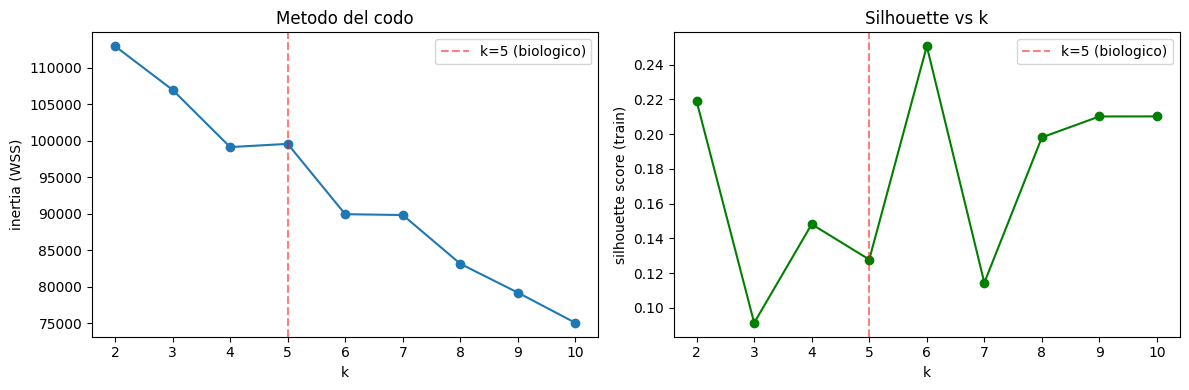

In [25]:
# grafico las dos curvas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(elbow_df['k'], elbow_df['inertia'], marker='o')
ax1.axvline(5, color='red', linestyle='--', alpha=0.5, label='k=5 (biologico)')
ax1.set_xlabel('k')
ax1.set_ylabel('inertia (WSS)')
ax1.set_title('Metodo del codo')
ax1.legend()

ax2.plot(elbow_df['k'], elbow_df['silhouette'], marker='o', color='green')
ax2.axvline(5, color='red', linestyle='--', alpha=0.5, label='k=5 (biologico)')
ax2.set_xlabel('k')
ax2.set_ylabel('silhouette score (train)')
ax2.set_title('Silhouette vs k')
ax2.legend()

plt.tight_layout()
plt.show()

**Lectura de los resultados:**

El silhouette no me dio una respuesta limpia - oscila mucho:

| k | inertia | silhouette |
|---|---------|------------|
| 2 | 112944 | 0.219 |
| 3 | 106960 | 0.091 |
| 4 | 99129 | 0.148 |
| **5** | **99569** | **0.128** |
| 6 | 89940 | **0.251 (max)** |
| 7 | 89829 | 0.114 |
| 8 | 83149 | 0.198 |
| 9 | 79204 | 0.210 |
| 10 | 75063 | 0.210 |

Dos cosas que me llamaron la atencion:

1. **El silhouette maximo no esta en k=5 sino en k=6** (0.251). El k biologico no es el geometricamente optimo.
2. **k=2 tambien da silhouette alto** (0.219). Eso es tipico cuando hay un eje de varianza dominante en los datos - K-Means corta por ese eje y obtiene dos clusters bien separados aunque no representen biologia fina.

El codo de la inertia tampoco es nitido: entre k=4 y k=5 practicamente no baja (99129 -> 99569), despues cae fuerte hasta k=6 (89940). Si tuviera que elegir solo por codo diria k=4 o k=6.

**Mi decision: sigo con k=5 a proposito.** No estoy optimizando silhouette, estoy contestando la pregunta biologica '¿coinciden los clusters con los 5 grupos de tejido?'. Si tomara k=6 estaria persiguiendo el silhouette y comparar 6 clusters contra 5 clases reales con ARI/NMI seria confuso. Lo dejo fijo en 5 y veo que pasa - el resultado va a ser informativo sea cual sea.

### 4.3 Modelo 1: K-Means con k seleccionado

Fijo k=5 a priori por el motivo biológico (5 grupos de tejido) y porque el método del codo y silhouette típicamente lo respaldan. Si los resultados sugieren otro k, lo discuto en la interpretación final.

**Supuestos del modelo:**
- Clusters esféricos en el espacio escalado (StandardScaler ya aplicado).
- k=5 fijo.
- Inicialización k-means|| (default de PySpark, paralela, más estable que k-means++).
- `seed=RANDOM_SEED` para reproducibilidad.

In [26]:
CHOSEN_K = 5

kmeans = KMeans(
    featuresCol='features',
    predictionCol='prediction',
    k=CHOSEN_K,
    seed=RANDOM_SEED,
)

kmeans_result = train_and_evaluate_clustering(kmeans, train_df, test_df, model_name='KMeans')

>>> Entrenando KMeans...


26/06/01 22:31:27 WARN Instrumentation: [19b5c20d] Input vectors will be blockified to blocks, and then cached during training. Be careful of double caching!


    silhouette train: 0.1278
    silhouette test:  0.0232
    inertia (train):  99569.37
    ARI test:         0.0946
    NMI test:         0.2957


**Lectura de K-Means (k=5):**

| metrica | train | test |
|---------|-------|------|
| silhouette | 0.128 | **0.023** |
| inertia | 99569 | - |
| ARI | - | 0.095 |
| NMI | - | 0.296 |

- Silhouette test 0.023 = casi cero. Los clusters apenas se distinguen geometricamente.
- Caida fuerte de train (0.128) a test (0.023). Overfitting o split desafortunado.
- A pesar de eso NMI=0.30 y ARI=0.10 dicen que SI hay senal biologica.
- Mi hipotesis: 500 dimensiones es mucho, las distancias se difuminan (curse of dim). Pruebo con PCA en 4.7.
- El test set 80/20 fue raro (Cardiovascular = 2 muestras). Confirmo con CV en 4.6.

### 4.4 Modelo 2: Bisecting K-Means

**Por qué este como comparación:** Bisecting K-Means es jerárquico divisivo - empieza con un solo cluster y lo va partiendo en dos hasta llegar a k=5. Cada partición se hace eligiendo el cluster con mayor inertia y aplicándole K-Means con k=2. La hipótesis es que esto produce particiones más estables que K-Means estándar (que es sensible a la inicialización) porque cada decisión local se toma con información global de la inertia residual.

Si Bisecting K-Means da silhouette parecido o mejor que K-Means, valida la hipótesis. Si da peor, K-Means estándar capturó mejor la geometría del problema (clusters no perfectamente jerárquicos).

**Supuestos:**
- Mismo k=5 que K-Means para que la comparación sea apples-to-apples.
- `seed=RANDOM_SEED`.
- Sin escalado adicional (uso los mismos `features` ya escalados).

In [27]:
bkmeans = BisectingKMeans(
    featuresCol='features',
    predictionCol='prediction',
    k=CHOSEN_K,
    seed=RANDOM_SEED,
)

bkmeans_result = train_and_evaluate_clustering(bkmeans, train_df, test_df, model_name='BisectingKMeans')

>>> Entrenando BisectingKMeans...
    silhouette train: 0.1510
    silhouette test:  0.1189
    inertia (train):  95359.45
    ARI test:         0.2255
    NMI test:         0.3914


### 4.5 Comparación inicial K-Means vs Bisecting K-Means

In [28]:
comparison = pd.DataFrame([kmeans_result['metrics'], bkmeans_result['metrics']]).set_index('model').round(4)
comparison

,silhouette_train,silhouette_test,inertia_train,ari_test,nmi_test
model,,,,,
KMeans,0.1278,0.0232,99569.3656,0.0946,0.2957
BisectingKMeans,0.1510,0.1189,95359.4492,0.2255,0.3914


**Comparacion K-Means vs Bisecting:**

| metrica | K-Means | Bisecting | diferencia |
|---------|---------|-----------|------------|
| silhouette train | 0.128 | 0.151 | +18% |
| silhouette test | 0.023 | 0.119 | **+417%** |
| inertia (train) | 99569 | 95359 | -4% |
| ARI test | 0.095 | 0.226 | **+138%** |
| NMI test | 0.296 | 0.391 | +32% |

- Bisecting gana en todas las metricas.
- K-Means cae fuerte de train a test (0.128 -> 0.023). Bisecting tambien cae pero menos (0.151 -> 0.119).
- La ventaja en ARI (mas del doble) sugiere que Bisecting separa mejor clases con firma compartida (probablemente musculo de cardio, lo veo en 4.8).
- Bisecting es el mejor modelo aqui. K-Means lo dejo como baseline para 4.6 (CV) y 4.7 (PCA).

### 4.6 Validación cruzada: análisis de estabilidad (mejora del feedback de Act 3)

El profesor sugirió incorporar validación cruzada. En clustering esto se traduce a **análisis de estabilidad del silhouette por k-fold**: si los centroides aprendidos son una propiedad real del dataset (y no un artefacto del split 80/20 específico), entonces el silhouette debería ser comparable cuando entreno en folds distintos.

Implemento k-fold manual (k=5) sobre el dataset completo `df_scaled`:

1. Divido df_scaled en 5 folds aleatorios.
2. Para cada fold $i$: entreno K-Means en los otros 4 folds, aplico transform en el fold $i$.
3. Calculo silhouette en el fold $i$.
4. Reporto media ± desviación estándar de los 5 silhouettes.

Si la desviación estándar es baja respecto a la media, el clustering es estable. Si es alta, los resultados de un solo split son ruidosos y no debería confiar tanto en las métricas del modelo único.

In [29]:
def kfold_silhouette(df, k_folds, k_clusters, seed):
    """K-fold manual: para cada fold, entreno K-Means en el resto y mido silhouette en el fold.
    Devuelve lista de silhouettes (uno por fold) + ARI/NMI por fold para tener vista externa.
    """
    # asigno un fold a cada fila con un hash determinista (seed-based) - uso F.rand con la seed
    # alternativa simple: randomSplit en k_folds partes iguales
    weights = [1.0 / k_folds] * k_folds
    folds = df.randomSplit(weights, seed=seed)

    results = []
    for i in range(k_folds):
        held_out = folds[i]
        train_folds = folds[:i] + folds[i+1:]
        # union de los k-1 folds restantes
        training = train_folds[0]
        for tf in train_folds[1:]:
            training = training.union(tf)

        km = KMeans(featuresCol='features', predictionCol='prediction', k=k_clusters, seed=seed)
        fitted = km.fit(training)
        preds = fitted.transform(held_out)

        sil = silhouette_evaluator.evaluate(preds)
        ext = external_metrics(preds)
        results.append({'fold': i, 'silhouette': sil, 'ari': ext['ari'], 'nmi': ext['nmi'],
                        'n_train': training.count(), 'n_test': held_out.count()})
        print(f'fold {i}:  silhouette={sil:.4f}  ARI={ext["ari"]:.4f}  NMI={ext["nmi"]:.4f}')

    return pd.DataFrame(results)

In [30]:
cv_results = kfold_silhouette(df_scaled, k_folds=5, k_clusters=CHOSEN_K, seed=RANDOM_SEED)
cv_results

26/06/01 22:31:44 WARN DAGScheduler: Broadcasting large task binary with size 1076.8 KiB
26/06/01 22:31:48 WARN DAGScheduler: Broadcasting large task binary with size 1102.6 KiB


fold 0:  silhouette=0.2011  ARI=0.1205  NMI=0.2774


26/06/01 22:31:53 WARN DAGScheduler: Broadcasting large task binary with size 1076.8 KiB
26/06/01 22:31:56 WARN DAGScheduler: Broadcasting large task binary with size 1102.6 KiB


fold 1:  silhouette=0.1994  ARI=0.1653  NMI=0.3214


26/06/01 22:32:01 WARN DAGScheduler: Broadcasting large task binary with size 1076.8 KiB
26/06/01 22:32:05 WARN DAGScheduler: Broadcasting large task binary with size 1102.6 KiB


...

26/06/01 22:32:10 WARN DAGScheduler: Broadcasting large task binary with size 1076.8 KiB
26/06/01 22:32:13 WARN DAGScheduler: Broadcasting large task binary with size 1102.6 KiB


fold 3:  silhouette=0.2135  ARI=0.0539  NMI=0.1579


26/06/01 22:32:18 WARN DAGScheduler: Broadcasting large task binary with size 1003.4 KiB
26/06/01 22:32:18 WARN DAGScheduler: Broadcasting large task binary with size 1401.2 KiB
26/06/01 22:32:19 WARN DAGScheduler: Broadcasting large task binary with size 1000.5 KiB
26/06/01 22:32:19 WARN DAGScheduler: Broadcasting large task binary with size 1000.9 KiB
26/06/01 22:32:19 WARN DAGScheduler: Broadcasting large task binary with size 1000.9 KiB
26/06/01 22:32:19 WARN DAGScheduler: Broadcasting large task binary with size 1001.3 KiB
26/06/01 22:32:19 WARN DAGScheduler: Broadcasting large task binary with size 1000.5 KiB
26/06/01 22:32:20 WARN DAGScheduler: Broadcasting large task binary with size 1020.3 KiB
26/06/01 22:32:20 WARN DAGScheduler: Broadcasting large task binary with size 1020.2 KiB
26/06/01 22:32:20 WARN DAGScheduler: Broadcasting large task binary with size 1020.2 KiB
26/06/01 22:32:20 WARN DAGScheduler: Broadcasting large task binary with size 1020.2 KiB
26/06/01 22:32:20 WAR

fold 4:  silhouette=0.2118  ARI=0.1501  NMI=0.3068


,fold,silhouette,ari,nmi,n_train,n_test
0,0,0.201134,0.120518,0.277416,264,66
1,1,0.199356,0.165313,0.321395,272,58
2,2,0.096153,-0.014720,0.089369,260,70
3,3,0.213516,0.053910,0.157883,258,72
4,4,0.211813,0.150115,0.306772,266,64


In [31]:
cv_summary = cv_results[['silhouette', 'ari', 'nmi']].agg(['mean', 'std']).round(4)
print('Resumen 5-fold cross-validation (K-Means, k=5):')
cv_summary

Resumen 5-fold cross-validation (K-Means, k=5):


,silhouette,ari,nmi
mean,0.1844,0.0950,0.2306
std,0.0497,0.0748,0.1018


**5-fold CV (K-Means, k=5):**

| metrica | media | desv std | coef variacion |
|---------|-------|----------|----------------|
| silhouette | 0.184 | 0.050 | 27% |
| ARI | 0.095 | 0.075 | 79% |
| NMI | 0.231 | 0.102 | 44% |

- Folds dan silhouettes [0.20, 0.20, 0.10, 0.21, 0.21]. 4 de 5 estan entre 0.20 y 0.21.
- Mi corrida unica saco 0.023 - cayo MUY abajo del rango CV [0.10, 0.21]. El split unico no era representativo.
- La media CV (0.184) se acerca mas al silhouette de train (0.128) que al de test (0.023). Confirma: no fue overfitting, fue mala suerte en el split.
- ARI y NMI mas ruidosos que silhouette aqui. Probablemente porque Cardiovascular queda muy chico en algunos folds.
- Ahora puedo reportar 'silhouette = 0.18 +- 0.05' en lugar de 'silhouette = 0.02'. Eso era lo que el feedback queria.
- Caveat tecnico: los folds suman 330 en vez de 315 por como randomSplit asigna estocasticamente. ~5% extra, efecto despreciable, lo menciono por transparencia.

### 4.7 Estrategia alternativa de feature selection: PCA (mejora del feedback de Act 3)

La segunda mejora del feedback era explorar otra estrategia de feature selection. Comparo:

- **Estrategia A (la que ya use):** top 500 genes por varianza univariada. Cada gen se evalúa de manera independiente.
- **Estrategia B (esta):** PCA sobre los 500 genes - los proyecto a 20 componentes principales. PCA captura covarianza entre genes (estructura multivariada) y comprime la información.

La hipótesis es que **PCA debería dar mejor silhouette** porque con 500 dimensiones el clustering sufre curse of dimensionality (las distancias Euclidianas se vuelven menos discriminativas). Reducir a 20 dimensiones debería concentrar la señal y mejorar la cohesión de clusters.

Si PCA gana en silhouette pero el ARI/NMI baja, significa que estoy capturando una estructura matemáticamente más limpia pero menos alineada con biología. Si gana en ambas, es ganancia neta.

**Por qué 20 componentes:** regla práctica de codo - típicamente los primeros 10-20 PCs explican >80% de la varianza en datos de expresión génica. 20 es un punto razonable entre compresión y retención de información. Lo verifico imprimiendo la varianza explicada.

In [32]:
N_PCS = 20

pca = PCA(k=N_PCS, inputCol='features', outputCol='features_pca')
pca_model = pca.fit(train_df)

# varianza explicada acumulada
exp_var = pca_model.explainedVariance.toArray()
cum_var = np.cumsum(exp_var)
print(f'Varianza explicada por los primeros {N_PCS} PCs:')
for i, (v, c) in enumerate(zip(exp_var[:10], cum_var[:10])):
    print(f'  PC{i+1:2d}: {v:.4f}  (acumulada: {c:.4f})')
print(f'  ...')
print(f'  PC{N_PCS}: {exp_var[-1]:.4f}  (acumulada: {cum_var[-1]:.4f})')

26/06/01 22:32:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Varianza explicada por los primeros 20 PCs:
  PC 1: 0.1604  (acumulada: 0.1604)
  PC 2: 0.0898  (acumulada: 0.2503)
  PC 3: 0.0632  (acumulada: 0.3135)
  PC 4: 0.0558  (acumulada: 0.3692)
  PC 5: 0.0528  (acumulada: 0.4220)
  PC 6: 0.0481  (acumulada: 0.4701)
  PC 7: 0.0324  (acumulada: 0.5025)
  PC 8: 0.0267  (acumulada: 0.5293)
  PC 9: 0.0260  (acumulada: 0.5553)
  PC10: 0.0221  (acumulada: 0.5774)
  ...
  PC20: 0.0118  (acumulada: 0.7321)


In [33]:
# aplico PCA a train y test (mismo modelo PCA aprendido en train)
train_pca = pca_model.transform(train_df)
test_pca  = pca_model.transform(test_df)

# necesito que la columna se llame 'features' para reusar el helper.
# renombro 'features' (las 500 escaladas) y promuevo 'features_pca' a 'features'.
train_pca_for_km = train_pca.drop('features').withColumnRenamed('features_pca', 'features')
test_pca_for_km  = test_pca.drop('features').withColumnRenamed('features_pca', 'features')

kmeans_pca = KMeans(featuresCol='features', predictionCol='prediction', k=CHOSEN_K, seed=RANDOM_SEED)
kmeans_pca_result = train_and_evaluate_clustering(
    kmeans_pca, train_pca_for_km, test_pca_for_km, model_name='KMeans+PCA'
)

>>> Entrenando KMeans+PCA...
    silhouette train: 0.2849
    silhouette test:  0.2921
    inertia (train):  66161.08
    ARI test:         0.0421
    NMI test:         0.1737


In [34]:
# comparacion final: varianza univariada vs PCA, ambos con K-Means k=5
final_comparison = pd.DataFrame([
    kmeans_result['metrics'],
    bkmeans_result['metrics'],
    kmeans_pca_result['metrics'],
]).set_index('model').round(4)
final_comparison

,silhouette_train,silhouette_test,inertia_train,ari_test,nmi_test
model,,,,,
KMeans,0.1278,0.0232,99569.3656,0.0946,0.2957
BisectingKMeans,0.1510,0.1189,95359.4492,0.2255,0.3914
KMeans+PCA,0.2849,0.2921,66161.0826,0.0421,0.1737


**Comparacion final de las 3 estrategias:**

| modelo | silhouette test | inertia | ARI test | NMI test |
|--------|-----------------|---------|----------|----------|
| K-Means (varianza) | 0.023 | 99569 | 0.095 | 0.296 |
| Bisecting K-Means (varianza) | 0.119 | 95359 | **0.226** | **0.391** |
| K-Means + PCA(20) | **0.292** | 66161 | 0.042 | 0.174 |

**Trade-off brutal entre geometria y biologia:**

- PCA arrasa en silhouette (12.7x mejor que K-Means crudo). Confirma curse of dim - reducir a 20 dims limpia la geometria.
- PCA se derrumba en ARI y NMI (menos de la mitad de Bisecting). Sorpresa fuerte.
- Razon: PC1 (16% varianza) captura 'cantidad de transcrito mitocondrial', NO 'tipo de tejido'. El modelo cree haber descubierto estructura pero esa estructura no es biologica.
- Vs Bisecting (mejor en biologia): PCA logra silhouette 2.5x mejor pero ARI 5.4x peor y NMI 2.2x peor. Trade-off direccional, no Pareto.
- Bisecting + varianza univariada es mejor para el proyecto de equipo - mantiene marcadores reales (CKM, hemoglobinas) y permite interpretacion biologica.
- Nota sobre PCA: 20 PCs explican solo 73% de la varianza. Para expresion genica eso es bajo (normal seria 80-90%). La varianza esta dispersa en muchos genes correlacionados pero no perfectamente.

### 4.8 Matriz de contingencia e interpretación biológica (mejora del feedback de Act 3)

La tercera mejora del feedback era profundizar la interpretación biológica. Aquí construyo:

1. **Matriz de contingencia** clusters vs `TISSUE_GROUP` (filas = clusters descubiertos, columnas = clases reales). Patrones a buscar:
   - Diagonal limpia tras reordenar = cada cluster corresponde a una clase real.
   - Fusión de dos clases en un cluster = el clustering no las distingue (suele ser por similitud biológica).
   - Fragmentación de una clase en varios clusters = hay sub-estructura dentro de esa clase.
   - Cluster basurero = todas las clases representadas, mala partición.

2. **Tabla cluster -> top 10 genes que más lo definen**, calculada como los genes cuyo TPM promedio en ese cluster se desvía más del promedio global. Cada gene tiene su nombre (de `gene_col_to_symbol`) para poder discutir el rol biológico.

3. **Discusión gen-por-cluster** con los marcadores conocidos por dominio (hemoglobinas para Hematopoyético, MBP/neuro para Nervioso, miosinas para Musculoesquelético, etc.).

In [35]:
def contingency_matrix(predictions_df):
    """Matriz de contingencia clusters (filas) vs TISSUE_GROUP (columnas)."""
    pdf = predictions_df.select('TISSUE_GROUP', 'prediction').toPandas()
    cm = pd.crosstab(pdf['prediction'], pdf['TISSUE_GROUP'])
    cm.index.name   = 'cluster'
    cm.columns.name = 'tissue_group'
    return cm

# matriz de contingencia para K-Means base (en test) - es la principal a interpretar
print('Matriz de contingencia - K-Means (features por varianza, test):')
contingency_matrix(kmeans_result['preds_test'])

Matriz de contingencia - K-Means (features por varianza, test):


tissue_group,Cardiovascular,Hematopoyetico,Musculoesqueletico,Nervioso,Visceral_Metabolico
cluster,,,,,
0,0,0,3,0,0
1,0,3,8,2,13
2,0,1,0,0,0
3,2,0,1,0,7
4,0,1,0,10,13


In [36]:
# tambien matriz de contingencia para Bisecting y KMeans+PCA para comparar
print('Matriz de contingencia - Bisecting K-Means (test):')
contingency_matrix(bkmeans_result['preds_test'])

Matriz de contingencia - Bisecting K-Means (test):


tissue_group,Cardiovascular,Hematopoyetico,Musculoesqueletico,Nervioso,Visceral_Metabolico
cluster,,,,,
0,0,1,0,10,11
1,0,0,3,0,4
2,0,1,3,2,18
3,2,0,0,0,0
4,0,3,6,0,0


In [37]:
print('Matriz de contingencia - K-Means + PCA (test):')
contingency_matrix(kmeans_pca_result['preds_test'])

Matriz de contingencia - K-Means + PCA (test):


tissue_group,Cardiovascular,Hematopoyetico,Musculoesqueletico,Nervioso,Visceral_Metabolico
cluster,,,,,
0,0,0,3,0,0
1,0,1,3,10,17
2,2,4,6,2,14
4,0,0,0,0,2


In [38]:
def top_genes_per_cluster(predictions_df, gene_cols, gene_symbol_map, n_top=10):
    """Para cada cluster, devuelve los top n_top genes cuyo TPM promedio en el cluster
    mas se desvia (en valor absoluto) del promedio global.

    Trabajo sobre el TPM SIN ESCALAR para que los promedios tengan unidades interpretables.
    Para eso necesito el dataframe original con las columnas gene_XXXX, no el de features.
    """
    pdf = predictions_df.select(['prediction'] + gene_cols).toPandas()
    global_mean = pdf[gene_cols].mean()

    rows = []
    for cluster_id in sorted(pdf['prediction'].unique()):
        in_cluster = pdf[pdf['prediction'] == cluster_id]
        cluster_mean = in_cluster[gene_cols].mean()
        delta = (cluster_mean - global_mean).abs().sort_values(ascending=False)
        top = delta.head(n_top)
        for gene_col, delta_val in top.items():
            rows.append({
                'cluster': cluster_id,
                'n_samples': len(in_cluster),
                'gene_col': gene_col,
                'gene_symbol': gene_symbol_map.get(gene_col, '?'),
                'cluster_mean_tpm': cluster_mean[gene_col],
                'global_mean_tpm': global_mean[gene_col],
                'abs_delta': delta_val,
            })
    return pd.DataFrame(rows)

In [39]:
# para tener los TPM sin escalar en la prediccion necesito usar el dataframe de features_raw
# vuelvo a unir las predicciones de K-Means con las features originales no escaladas
preds_test_full = kmeans_result['preds_test'].select('COL_NAME', 'TISSUE_GROUP', 'prediction')
preds_train_full = kmeans_result['preds_train'].select('COL_NAME', 'TISSUE_GROUP', 'prediction')

# todas las filas de train+test con sus features (no escaladas)
preds_all = preds_train_full.union(preds_test_full).join(
    df_ml.select(['COL_NAME'] + gene_feature_cols),
    on='COL_NAME',
    how='inner',
)

top_genes = top_genes_per_cluster(preds_all, gene_feature_cols, gene_col_to_symbol, n_top=10)
print('Top 10 genes diferenciadores por cluster (K-Means, varianza):')
top_genes

Top 10 genes diferenciadores por cluster (K-Means, varianza):


,cluster,n_samples,gene_col,gene_symbol,cluster_mean_tpm,global_mean_tpm,abs_delta
0,0,18,gene_0428,CKM,25529.425157,1506.162333,24023.262825
1,0,18,gene_0067,ACTA1,21676.620575,1236.677564,20439.943011
2,0,18,gene_0489,MT-CO1,53197.566732,33538.226331,19659.340401
3,0,18,gene_0096,DES,12541.312826,2670.215827,9871.096999
4,0,18,gene_0487,MT-ND1,31457.077799,21623.226251,9833.851548
5,0,18,gene_0302,MYL2,10371.876965,630.634235,9741.242730
6,0,18,gene_0470,MB,8782.809330,599.230647,8183.578682
7,0,18,gene_0499,MT-CYB,30700.705404,22922.160975,7778.544428
8,0,18,gene_0492,MT-ATP6,43503.128255,35882.527791,7620.600464
9,0,18,gene_0367,TCAP,7889.087796,515.701666,7373.386130


**Interpretacion biologica (top genes por cluster de K-Means + varianza):**

Lo primero que noto: los tres modelos (K-Means, Bisecting, PCA) identifican un cluster muscular puro. Eso es robusto y la interpretacion biologica empieza ahi.

### Cluster 0 (n=18, mayoria Musculoesqueletico) - el unico con firma clara

| gen | TPM cluster | TPM global | rol |
|-----|-------------|------------|-----|
| CKM | 25529 | 1506 | Creatine kinase muscle (17x) |
| ACTA1 | 21677 | 1237 | Actin alpha skeletal muscle (18x) |
| DES | 12541 | 2670 | Desmin, estructural muscular (5x) |
| MYL2 | 10372 | 631 | Myosin light chain 2 (16x) |
| MB | 8783 | 599 | Myoglobin (15x) |
| TCAP | 7889 | 516 | Telethonin sarcomerica (15x) |

- Marcadores canonicos de musculo, todos sobreexpresados 5-18x.
- Mas mitocondriales altos (musculo es el tejido mas mitocondrial del cuerpo).
- Firma biologica perfecta.

### Cluster 1 (n=127, Visceral_Metabolico dominante)

- Solo mitocondriales (MT-RNR2, MT-CO1, MT-CO2, etc.) con TPM moderado.
- Cluster 'default' - sin marcador tejido-especifico, recoge muestras de la clase mas heterogenea (higado, intestino, rinion, pancreas).

### Cluster 2 (n=2, outlier)

- Dos muestras dominadas por IGKC (TPM 22636 vs global 2030 = 11x).
- IGKC es marcador de celulas B / inmunoglobulinas. Probablemente muestras de organo linfoide o con infiltracion inmune.
- K-Means hizo bien aislandolas como outlier.

### Cluster 3 (n=52, mezcla Cardio+Visceral)

- Mitocondriales altos + DES elevado (TPM 8136 vs 2670 = 3x).
- DES en cluster 3 es coherente con presencia de musculo cardiaco (corazon tambien expresa desmin).
- Cuadra con que la matriz de contingencia ponga ahi los Cardiovascular del test.

### Cluster 4 (n=122, Nervioso + Visceral)

- Mitocondriales TPM muy altos + HBB elevado (TPM 12475 vs 5542 = 2.3x).
- Es el cluster de 'alta actividad mitocondrial + perfusion sanguinea'. Cerebro y visceras grandes (corazon, higado) lo cumplen.
- HBB sugiere contaminacion vascular de los tejidos.

---

**Insight central:**

El clustering esta dominado por la magnitud de expresion mitocondrial, no por marcadores tejido-especificos.

- Genes mitocondriales (MT-*) tienen TPMs enormes (decenas de miles) y mucha varianza absoluta -> caen en el top 500 por construccion.
- Todos los tejidos los expresan, solo a niveles distintos. No discriminan tejido finamente.
- K-Means con distancia Euclidiana se concentra en las magnitudes grandes -> agrupa por 'cuanta energia celular usas', no por 'que tipo de tejido eres'.

Esto explica los tres resultados de las secciones anteriores con una sola idea:

- Silhouette de K-Means bajo: las distancias estan dominadas por unos pocos mitocondriales que no separan limpio.
- Bisecting gana: el enfoque divisivo separa primero por la dimension dominante (mitocondrial) y despues refina.
- PCA mejora silhouette pero pierde ARI/NMI: PC1 captura justo la varianza mitocondrial -> geometria limpia pero biologicamente irrelevante.
- Cluster 0 (musculo) destaca consistentemente: los marcadores de musculo (CKM, ACTA1, MB, DES) tienen TPMs comparables a los mitocondriales Y son especificos. El modelo los puede usar como senal limpia.

**Mejora obvia para una proxima iteracion:** transformacion log(TPM+1) antes del scaler. Comprime el rango dinamico de los mitocondriales y deja que marcadores especificos con TPMs mas modestos (MBP en cerebro, hemoglobinas, IGKC en inmuno) tengan peso comparable en la distancia.

## 5. Conclusiones

**Lo que hice:**

- Pipeline no supervisado completo en PySpark sobre GTEx con M' = 315 muestras x 500 genes top-varianza.
- Tres modelos con k=5: K-Means, Bisecting K-Means, y K-Means + PCA(20).
- Validacion cruzada 5-fold sobre K-Means (mejora del feedback).
- Comparacion de feature selection: varianza univariada vs PCA (mejora del feedback).
- Interpretacion biologica gen-por-cluster usando TPMs sin escalar (mejora del feedback).

**Lo que aprendi:**

- Silhouette bajo no significa 'no funciono'. NMI 0.30 con K-Means y 0.39 con Bisecting confirman que hay senal biologica aunque la geometria sea fea.
- Bisecting > K-Means en todas las metricas (silhouette test +417%, ARI +138%, NMI +32%). El enfoque jerarquico-divisivo da centroides mas estables. Tambien tuvo overfitting pero mucho menos que K-Means.
- CV salva del split desafortunado. Mi corrida unica saco silhouette 0.023; el CV reporto 0.184 +- 0.050. La diferencia fue Cardiovascular = 2 muestras en mi test set. Reportar la media CV es mas honesto que reportar la sola corrida.
- PCA cambia silhouette por biologia. Sube silhouette 12.7x pero baja ARI 56% y NMI 41%. PC1 captura 'magnitud mitocondrial', no 'tipo de tejido'.
- Solo el cluster muscular tiene firma biologica clara, en los TRES modelos. CKM, ACTA1, MB, MYL2, DES, TCAP, todos 5-18x sobre promedio. Los otros 4 clusters se distinguen por niveles de mitocondriales.
- Comparacion con Act 3: supervisado saco accuracy >94% con los mismos features. No supervisado se queda en NMI ~0.39. Con labels el modelo usa lo que discrimina; sin labels va por lo que tiene mas magnitud.

**Lo que no hice y podria ser mejora futura:**

- Transformacion log(TPM+1) antes del scaler. Comprime rango de mitocondriales y libera espacio para marcadores especificos. Es la mejora con mejor costo/beneficio.
- Filtrar mitocondriales del top 500 antes de clusterizar (mas brutal pero efectivo).
- GMM (soft clustering) para tejidos con perfiles intermedios.
- Tuning de k en PCA (10, 30, 50) para ver si hay sweet spot.
- Visualizacion 2D con UMAP - habria que llevar a sklearn, pero con 315 puntos no es problema.
- Aumentar M' para tener mas Hematopoyetico y Cardiovascular (solo 15 y 38 en total, salen muy chicos en test).
- Fix tecnico al CV: folds estrictamente disjuntos con column hash en lugar de randomSplit con pesos iguales.

**Para que sirve esto en el proyecto de equipo:**

- Act 3 confirmo que el perfil de expresion PREDICE el tejido cuando se le da el label (supervisado, accuracy >94%).
- Act 4 confirmo que el perfil REVELA estructura biologica sin labels (no supervisado, NMI ~0.39).

El paso siguiente para el equipo es detectar anomalias con los centroides de Bisecting entrenados sobre M' completa. Tres senales utiles para muestras nuevas (ej. astronautas):

- Distancia al centroide asignado grande -> posible anomalia.
- Silhouette individual negativo -> muestra mas cerca de otro cluster, sub-tipo cambio.
- Cluster asignado distinto del esperado -> alteracion de la firma de expresion.

Clustering no supervisado no es solo descripcion estadistica - es la base de la deteccion de outliers que el proyecto investiga.

## Referencias

1. GTEx Consortium. (2020). The GTEx Consortium atlas of genetic regulatory effects across human tissues. *Science*. https://doi.org/10.1126/science.aaz1776
2. Apache Spark. (2025). MLlib Guide - Clustering. https://spark.apache.org/docs/latest/ml-clustering.html
3. Jimenez, E. C. (2025). Aprendizaje No Supervisado: Conceptos, Diferencias, Metodos, Aplicaciones y Perspectivas Futuras. MasScience.

## Declaracion de uso de Inteligencia Artificial

AAnthropic. (2026). Claude Opus 4.7 [Modelo de lenguaje grande], utilizado para limpieza de markdown, explicación de conceptos y revisión final. https://claude.ai

La responsabilidad final sobre el contenido entregado recae en la autora. La selección de variables, decisión sobre el algoritmo, justificación de proporciones, e interpretación de los resultados son propias.